<a href="https://colab.research.google.com/github/AleSSandroArij/BUSSINES-ANALYTICS/blob/main/Feature_Engineering_Examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Metadata

This synthetic dataset represents customer purchase transactions from an e-commerce platform. It is designed for practicing feature engineering techniques, including feature transformations, temporal features, interaction features, aggregated features, and categorical encoding.

Each row corresponds to a single purchase, meaning that the same customer may appear multiple times throughout the dataset.

- **customer_id:** Unique identifier for each customer. A customer may appear multiple times because each row represents a different purchase.
- **income:** Customer's annual income. Useful for demonstrating skewed distributions and feature transformations.
- **debt:** Customer's total outstanding debt. Can be combined with income to create interaction features.
- **plan:** Customer membership level (`basic`, `silver`, `gold`, `premium`).
- **city:** Customer's city of residence.
- **purchase_timestamp:** Date and time when the purchase occurred.
- **purchase_amount:** Amount spent in the transaction.
- **failed_payments:** Number of failed payment attempts associated with the purchase.
- **default:** Binary target variable indicating whether the customer eventually defaulted (`1`) or not (`0`).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer

# =========================================================
# MINI DATASET BASE
# =========================================================

data = [
    # customer_id, income, debt, plan, city, purchase_timestamp, purchase_amount, failed_payments, default
    [1,  25000,   5000, "basic",   "Madrid",    "2026-01-02 10:15:00",   35.0, 0, 0],
    [1,  25000,   5000, "basic",   "Madrid",    "2026-01-10 18:40:00",   48.0, 0, 0],
    [1,  25000,   5000, "basic",   "Madrid",    "2026-02-05 13:20:00",   22.0, 1, 0],

    [2,  48000,  15000, "silver",  "Barcelona", "2026-01-03 09:00:00",  120.0, 0, 0],
    [2,  48000,  15000, "silver",  "Barcelona", "2026-01-15 20:10:00",  180.0, 0, 0],
    [2,  48000,  15000, "silver",  "Barcelona", "2026-02-20 11:30:00",  260.0, 0, 0],

    [3, 120000,  30000, "gold",    "Valencia",  "2026-01-04 22:05:00",  500.0, 1, 1],
    [3, 120000,  30000, "gold",    "Valencia",  "2026-01-20 12:45:00",  750.0, 1, 1],
    [3, 120000,  30000, "gold",    "Valencia",  "2026-02-01 08:30:00",  900.0, 2, 1],

    [4,  70000,   8000, "silver",  "Sevilla",   "2026-01-06 14:00:00",   65.0, 0, 0],
    [4,  70000,   8000, "silver",  "Sevilla",   "2026-01-18 16:20:00",   95.0, 0, 0],
    [4,  70000,   8000, "silver",  "Sevilla",   "2026-02-10 10:50:00",  140.0, 0, 0],

    [5, 300000,  60000, "premium", "Bilbao",    "2026-01-08 07:30:00", 1500.0, 2, 1],
    [5, 300000,  60000, "premium", "Bilbao",    "2026-01-25 19:15:00", 2200.0, 1, 1],
    [5, 300000,  60000, "premium", "Bilbao",    "2026-02-14 21:45:00", 3100.0, 3, 1],

    [6,  42000,   2000, "basic",   "Madrid",    "2026-01-12 12:00:00",   18.0, 0, 0],
    [6,  42000,   2000, "basic",   "Madrid",    "2026-01-29 12:30:00",   27.0, 0, 0],
    [6,  42000,   2000, "basic",   "Madrid",    "2026-02-18 13:00:00",   19.0, 0, 0],
]

df = pd.DataFrame(
    data,
    columns=[
        "customer_id", "income", "debt", "plan", "city",
        "purchase_timestamp", "purchase_amount", "failed_payments", "default"
    ]
)

df["purchase_timestamp"] = pd.to_datetime(df["purchase_timestamp"])

df


,customer_id,income,debt,plan,city,purchase_timestamp,purchase_amount,failed_payments,default
0,1,25000,5000,basic,Madrid,2026-01-02 10:15:00,35.0,0,0
1,1,25000,5000,basic,Madrid,2026-01-10 18:40:00,48.0,0,0
2,1,25000,5000,basic,Madrid,2026-02-05 13:20:00,22.0,1,0
3,2,48000,15000,silver,Barcelona,2026-01-03 09:00:00,120.0,0,0
4,2,48000,15000,silver,Barcelona,2026-01-15 20:10:00,180.0,0,0
5,2,48000,15000,silver,Barcelona,2026-02-20 11:30:00,260.0,0,0
6,3,120000,30000,gold,Valencia,2026-01-04 22:05:00,500.0,1,1
7,3,120000,30000,gold,Valencia,2026-01-20 12:45:00,750.0,1,1
8,3,120000,30000,gold,Valencia,2026-02-01 08:30:00,900.0,2,1
9,4,70000,8000,silver,Sevilla,2026-01-06 14:00:00,65.0,0,0


<Axes: >

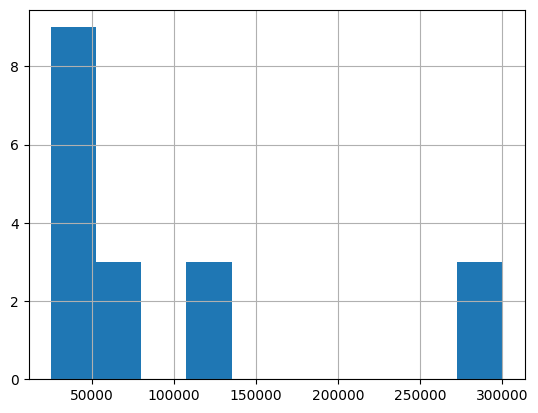

In [ ]:
df.income.hist()

In [ ]:
# =========================================================
# 1) FEATURE TRANSFORMATIONS
# =========================================================

# 1.1 Log transform: for skewed distributions
df["income_log"] = np.log1p(df["income"])

# 1.2 Standardization
scaler = StandardScaler()
df["income_standardized"] = scaler.fit_transform(df[["income"]])

# 1.3 Normalization
minmax = MinMaxScaler()
df["income_normalized"] = minmax.fit_transform(df[["income"]])

<Axes: >

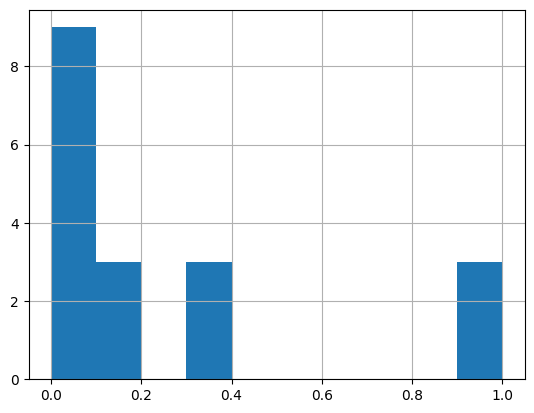

In [ ]:
df.income_normalized.hist()

In [ ]:
df

,customer_id,income,debt,plan,city,purchase_timestamp,purchase_amount,failed_payments,default,income_log,income_standardized,income_normalized
0,1,25000,5000,basic,Madrid,2026-01-02 10:15:00,35.0,0,0,10.126671,-0.806944,0.000000
1,1,25000,5000,basic,Madrid,2026-01-10 18:40:00,48.0,0,0,10.126671,-0.806944,0.000000
2,1,25000,5000,basic,Madrid,2026-02-05 13:20:00,22.0,1,0,10.126671,-0.806944,0.000000
3,2,48000,15000,silver,Barcelona,2026-01-03 09:00:00,120.0,0,0,10.778977,-0.562201,0.083636
4,2,48000,15000,silver,Barcelona,2026-01-15 20:10:00,180.0,0,0,10.778977,-0.562201,0.083636
5,2,48000,15000,silver,Barcelona,2026-02-20 11:30:00,260.0,0,0,10.778977,-0.562201,0.083636
6,3,120000,30000,gold,Valencia,2026-01-04 22:05:00,500.0,1,1,11.695255,0.203953,0.345455
7,3,120000,30000,gold,Valencia,2026-01-20 12:45:00,750.0,1,1,11.695255,0.203953,0.345455
8,3,120000,30000,gold,Valencia,2026-02-01 08:30:00,900.0,2,1,11.695255,0.203953,0.345455
9,4,70000,8000,silver,Sevilla,2026-01-06 14:00:00,65.0,0,0,11.156265,-0.328098,0.163636


In [ ]:
# =========================================================
# 2) DERIVED FEATURES FROM TIME
# =========================================================

df["day_of_week"] = df["purchase_timestamp"].dt.day_name()
df["month"] = df["purchase_timestamp"].dt.month
df["quarter"] = df["purchase_timestamp"].dt.quarter
df["is_weekend"] = df["purchase_timestamp"].dt.dayofweek.isin([5, 6]).astype(int)
df["is_business_hours"] = df["purchase_timestamp"].dt.hour.between(9, 18).astype(int)

# Holiday indicator
holiday_dates = pd.to_datetime(["2026-01-06", "2026-02-14"])
df["is_holiday"] = df["purchase_timestamp"].dt.normalize().isin(holiday_dates).astype(int)

print("\n=== 2) DERIVED FEATURES ===")
print(df[[
    "purchase_timestamp", "day_of_week", "month", "quarter",
    "is_weekend", "is_business_hours", "is_holiday"
]].head())


=== 2) DERIVED FEATURES ===
   purchase_timestamp day_of_week  month  quarter  is_weekend  \
0 2026-01-02 10:15:00      Friday      1        1           0   
1 2026-01-10 18:40:00    Saturday      1        1           1   
2 2026-02-05 13:20:00    Thursday      2        1           0   
3 2026-01-03 09:00:00    Saturday      1        1           1   
4 2026-01-15 20:10:00    Thursday      1        1           0   

   is_business_hours  is_holiday  
0                  1           0  
1                  1           0  
2                  1           0  
3                  1           0  
4                  0           0  


In [ ]:
df

,customer_id,income,debt,plan,city,purchase_timestamp,purchase_amount,failed_payments,default,income_log,income_standardized,income_normalized,day_of_week,month,quarter,is_weekend,is_business_hours,is_holiday
0,1,25000,5000,basic,Madrid,2026-01-02 10:15:00,35.0,0,0,10.126671,-0.806944,0.000000,Friday,1,1,0,1,0
1,1,25000,5000,basic,Madrid,2026-01-10 18:40:00,48.0,0,0,10.126671,-0.806944,0.000000,Saturday,1,1,1,1,0
2,1,25000,5000,basic,Madrid,2026-02-05 13:20:00,22.0,1,0,10.126671,-0.806944,0.000000,Thursday,2,1,0,1,0
3,2,48000,15000,silver,Barcelona,2026-01-03 09:00:00,120.0,0,0,10.778977,-0.562201,0.083636,Saturday,1,1,1,1,0
4,2,48000,15000,silver,Barcelona,2026-01-15 20:10:00,180.0,0,0,10.778977,-0.562201,0.083636,Thursday,1,1,0,0,0
5,2,48000,15000,silver,Barcelona,2026-02-20 11:30:00,260.0,0,0,10.778977,-0.562201,0.083636,Friday,2,1,0,1,0
6,3,120000,30000,gold,Valencia,2026-01-04 22:05:00,500.0,1,1,11.695255,0.203953,0.345455,Sunday,1,1,1,0,0
7,3,120000,30000,gold,Valencia,2026-01-20 12:45:00,750.0,1,1,11.695255,0.203953,0.345455,Tuesday,1,1,0,1,0
8,3,120000,30000,gold,Valencia,2026-02-01 08:30:00,900.0,2,1,11.695255,0.203953,0.345455,Sunday,2,1,1,0,0
9,4,70000,8000,silver,Sevilla,2026-01-06 14:00:00,65.0,0,0,11.156265,-0.328098,0.163636,Tuesday,1,1,0,1,1


In [ ]:
# =========================================================
# 3) INTERACTION FEATURES
# =========================================================

df["debt_to_income"] = df["debt"] / df["income"]
df["amount_to_income"] = df["purchase_amount"] / df["income"]

print("\n=== 3) INTERACTION FEATURES ===")
print(df[["income", "debt", "purchase_amount", "debt_to_income", "amount_to_income"]].head())


=== 3) INTERACTION FEATURES ===
   income   debt  purchase_amount  debt_to_income  amount_to_income
0   25000   5000             35.0          0.2000           0.00140
1   25000   5000             48.0          0.2000           0.00192
2   25000   5000             22.0          0.2000           0.00088
3   48000  15000            120.0          0.3125           0.00250
4   48000  15000            180.0          0.3125           0.00375


In [ ]:
df

,customer_id,income,debt,plan,city,purchase_timestamp,purchase_amount,failed_payments,default,income_log,income_standardized,income_normalized,day_of_week,month,quarter,is_weekend,is_business_hours,is_holiday,debt_to_income,amount_to_income
0,1,25000,5000,basic,Madrid,2026-01-02 10:15:00,35.0,0,0,10.126671,-0.806944,0.000000,Friday,1,1,0,1,0,0.200000,0.001400
1,1,25000,5000,basic,Madrid,2026-01-10 18:40:00,48.0,0,0,10.126671,-0.806944,0.000000,Saturday,1,1,1,1,0,0.200000,0.001920
2,1,25000,5000,basic,Madrid,2026-02-05 13:20:00,22.0,1,0,10.126671,-0.806944,0.000000,Thursday,2,1,0,1,0,0.200000,0.000880
3,2,48000,15000,silver,Barcelona,2026-01-03 09:00:00,120.0,0,0,10.778977,-0.562201,0.083636,Saturday,1,1,1,1,0,0.312500,0.002500
4,2,48000,15000,silver,Barcelona,2026-01-15 20:10:00,180.0,0,0,10.778977,-0.562201,0.083636,Thursday,1,1,0,0,0,0.312500,0.003750
5,2,48000,15000,silver,Barcelona,2026-02-20 11:30:00,260.0,0,0,10.778977,-0.562201,0.083636,Friday,2,1,0,1,0,0.312500,0.005417
6,3,120000,30000,gold,Valencia,2026-01-04 22:05:00,500.0,1,1,11.695255,0.203953,0.345455,Sunday,1,1,1,0,0,0.250000,0.004167
7,3,120000,30000,gold,Valencia,2026-01-20 12:45:00,750.0,1,1,11.695255,0.203953,0.345455,Tuesday,1,1,0,1,0,0.250000,0.006250
8,3,120000,30000,gold,Valencia,2026-02-01 08:30:00,900.0,2,1,11.695255,0.203953,0.345455,Sunday,2,1,1,0,0,0.250000,0.007500
9,4,70000,8000,silver,Sevilla,2026-01-06 14:00:00,65.0,0,0,11.156265,-0.328098,0.163636,Tuesday,1,1,0,1,1,0.114286,0.000929


In [ ]:
# =========================================================
# 4) AGGREGATED FEATURES
# =========================================================

# Temporal ordering before calculating accumulated features
df = df.sort_values(["customer_id", "purchase_timestamp"]).reset_index(drop=True)

# Accumulated totals by customer
df["purchase_count"] = df.groupby("customer_id").cumcount() + 1
df["lifetime_spending"] = df.groupby("customer_id")["purchase_amount"].cumsum()
df["max_transaction_value"] = df.groupby("customer_id")["purchase_amount"].cummax()

# Time since the previous purchase
df["time_since_last_purchase_days"] = (
    df.groupby("customer_id")["purchase_timestamp"].diff().dt.days
).fillna(-1)

# Aggregates summarized by client
customer_aggs = df.groupby("customer_id").agg(
    avg_purchase_amount=("purchase_amount", "mean"),
    max_purchase_amount=("purchase_amount", "max"),
    total_spending=("purchase_amount", "sum"),
    total_failed_payments=("failed_payments", "sum"),
    first_purchase=("purchase_timestamp", "min"),
    last_purchase=("purchase_timestamp", "max"),
    num_transactions=("purchase_amount", "size"),
).reset_index()

customer_aggs["customer_tenure_days"] = (
    customer_aggs["last_purchase"] - customer_aggs["first_purchase"]
).dt.days

df = df.merge(customer_aggs, on="customer_id", how="left")

print("\n=== 4) AGGREGATED FEATURES ===")
print(df[[
    "customer_id", "purchase_timestamp", "purchase_amount",
    "purchase_count", "lifetime_spending", "max_transaction_value",
    "time_since_last_purchase_days", "total_spending", "customer_tenure_days"
]].head(12))


=== 4) AGGREGATED FEATURES ===
    customer_id  purchase_timestamp  purchase_amount  purchase_count  \
0             1 2026-01-02 10:15:00             35.0               1   
1             1 2026-01-10 18:40:00             48.0               2   
2             1 2026-02-05 13:20:00             22.0               3   
3             2 2026-01-03 09:00:00            120.0               1   
4             2 2026-01-15 20:10:00            180.0               2   
5             2 2026-02-20 11:30:00            260.0               3   
6             3 2026-01-04 22:05:00            500.0               1   
7             3 2026-01-20 12:45:00            750.0               2   
8             3 2026-02-01 08:30:00            900.0               3   
9             4 2026-01-06 14:00:00             65.0               1   
10            4 2026-01-18 16:20:00             95.0               2   
11            4 2026-02-10 10:50:00            140.0               3   

    lifetime_spending  max_tran

In [ ]:
# =========================================================
# 5) CATEGORICAL ENCODING
# =========================================================

# 5.1 One-Hot Encoding
df_onehot = pd.get_dummies(df, columns=["plan", "city"], drop_first=False)

# 5.2 Ordinal Encoding
plan_order = {"basic": 1, "silver": 2, "gold": 3, "premium": 4}
df["plan_ordinal"] = df["plan"].map(plan_order)

# 5.3 Frequency Encoding
plan_freq = df["plan"].value_counts(normalize=True)
city_freq = df["city"].value_counts(normalize=True)

df["plan_freq"] = df["plan"].map(plan_freq)
df["city_freq"] = df["city"].map(city_freq)

# 5.4 Target Encoding simple
plan_target_mean = df.groupby("plan")["default"].mean()
df["plan_target_enc"] = df["plan"].map(plan_target_mean)

print("\n=== 5) CATEGORICAL ENCODING ===")
print(df[["plan", "plan_ordinal", "plan_freq", "plan_target_enc", "city", "city_freq"]].drop_duplicates().sort_values(["plan", "city"]))
print("\nOne-hot columns example:")
print(df_onehot.filter(regex="^plan_|^city_").head())


=== 5) CATEGORICAL ENCODING ===
       plan  plan_ordinal  plan_freq  plan_target_enc       city  city_freq
0     basic             1   0.333333              0.0     Madrid   0.333333
6      gold             3   0.166667              1.0   Valencia   0.166667
12  premium             4   0.166667              1.0     Bilbao   0.166667
3    silver             2   0.333333              0.0  Barcelona   0.166667
9    silver             2   0.333333              0.0    Sevilla   0.166667

One-hot columns example:
   plan_basic  plan_gold  plan_premium  plan_silver  city_Barcelona  \
0        True      False         False        False           False   
1        True      False         False        False           False   
2        True      False         False        False           False   
3       False      False         False         True            True   
4       False      False         False         True            True   

   city_Bilbao  city_Madrid  city_Sevilla  city_Valencia  

In [ ]:
# =========================================================
# 6) TEMPORAL FEATURES
# =========================================================

# Recency relative to a reference date
reference_date = pd.Timestamp("2026-03-01")
df["recency_days"] = (reference_date - df["last_purchase"]).dt.days

# Rolling mean by customer
df["rolling_mean_purchase_2"] = (
    df.groupby("customer_id")["purchase_amount"]
      .rolling(window=2, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

# RFM by customer
rfm = df.groupby("customer_id").agg(
    recency_days=("recency_days", "min"),
    frequency=("purchase_amount", "size"),
    monetary=("purchase_amount", "sum")
).reset_index()

print("\n=== 6) TEMPORAL FEATURES ===")
print(df[[
    "customer_id", "purchase_timestamp", "purchase_amount",
    "recency_days", "rolling_mean_purchase_2"
]].head(12))

print("\n=== RFM POR CLIENTE ===")
print(rfm)


=== 6) TEMPORAL FEATURES ===
    customer_id  purchase_timestamp  purchase_amount  recency_days  \
0             1 2026-01-02 10:15:00             35.0            23   
1             1 2026-01-10 18:40:00             48.0            23   
2             1 2026-02-05 13:20:00             22.0            23   
3             2 2026-01-03 09:00:00            120.0             8   
4             2 2026-01-15 20:10:00            180.0             8   
5             2 2026-02-20 11:30:00            260.0             8   
6             3 2026-01-04 22:05:00            500.0            27   
7             3 2026-01-20 12:45:00            750.0            27   
8             3 2026-02-01 08:30:00            900.0            27   
9             4 2026-01-06 14:00:00             65.0            18   
10            4 2026-01-18 16:20:00             95.0            18   
11            4 2026-02-10 10:50:00            140.0            18   

    rolling_mean_purchase_2  
0                      35.0  

In [ ]:
# =========================================================
# 7) FINAL DATASET
# =========================================================

df

,customer_id,income,debt,plan,city,purchase_timestamp,purchase_amount,failed_payments,default,income_log,...,first_purchase,last_purchase,num_transactions,customer_tenure_days,plan_ordinal,plan_freq,city_freq,plan_target_enc,recency_days,rolling_mean_purchase_2
0,1,25000,5000,basic,Madrid,2026-01-02 10:15:00,35.0,0,0,10.126671,...,2026-01-02 10:15:00,2026-02-05 13:20:00,3,34,1,0.333333,0.333333,0.0,23,35.0
1,1,25000,5000,basic,Madrid,2026-01-10 18:40:00,48.0,0,0,10.126671,...,2026-01-02 10:15:00,2026-02-05 13:20:00,3,34,1,0.333333,0.333333,0.0,23,41.5
2,1,25000,5000,basic,Madrid,2026-02-05 13:20:00,22.0,1,0,10.126671,...,2026-01-02 10:15:00,2026-02-05 13:20:00,3,34,1,0.333333,0.333333,0.0,23,35.0
3,2,48000,15000,silver,Barcelona,2026-01-03 09:00:00,120.0,0,0,10.778977,...,2026-01-03 09:00:00,2026-02-20 11:30:00,3,48,2,0.333333,0.166667,0.0,8,120.0
4,2,48000,15000,silver,Barcelona,2026-01-15 20:10:00,180.0,0,0,10.778977,...,2026-01-03 09:00:00,2026-02-20 11:30:00,3,48,2,0.333333,0.166667,0.0,8,150.0
5,2,48000,15000,silver,Barcelona,2026-02-20 11:30:00,260.0,0,0,10.778977,...,2026-01-03 09:00:00,2026-02-20 11:30:00,3,48,2,0.333333,0.166667,0.0,8,220.0
6,3,120000,30000,gold,Valencia,2026-01-04 22:05:00,500.0,1,1,11.695255,...,2026-01-04 22:05:00,2026-02-01 08:30:00,3,27,3,0.166667,0.166667,1.0,27,500.0
7,3,120000,30000,gold,Valencia,2026-01-20 12:45:00,750.0,1,1,11.695255,...,2026-01-04 22:05:00,2026-02-01 08:30:00,3,27,3,0.166667,0.166667,1.0,27,625.0
8,3,120000,30000,gold,Valencia,2026-02-01 08:30:00,900.0,2,1,11.695255,...,2026-01-04 22:05:00,2026-02-01 08:30:00,3,27,3,0.166667,0.166667,1.0,27,825.0
9,4,70000,8000,silver,Sevilla,2026-01-06 14:00:00,65.0,0,0,11.156265,...,2026-01-06 14:00:00,2026-02-10 10:50:00,3,34,2,0.333333,0.166667,0.0,18,65.0
